# Graph-enhanced Temporal-VAE: Nanzi demo workflow

This notebook runs the public package on a compact 96-hour excerpt from the Nanzi aerosol supersite record, using the preferred multimodal interface (`fit_multimodal` / `impute_multimodal`). It demonstrates the interface only: the excerpt is too small for scientifically valid reconstruction or calibrated uncertainty.

Workflow: split the excerpt into chemistry/PSD/meteorology modalities → validate the hourly grid → train a small model → inspect the self-contained bundle → impute natural gaps → inspect uncertainty and support-risk fields.

In [1]:
from pathlib import Path
import pandas as pd

from graph_temporal_vae import (
    InferenceConfig,
    ModalityPreprocessing,
    PreprocessingConfig,
    TrainConfig,
    fit_multimodal,
    impute_multimodal,
    inspect_bundle,
    validate_multimodal_data,
)

ROOT = Path.cwd()
if not (ROOT / 'examples').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data' / 'nanzi_demo_96h.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'nanzi_demo'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BUNDLE = OUTPUT_DIR / 'nanzi_demo_bundle.pt'
IMPUTED = OUTPUT_DIR / 'nanzi_demo_imputed.csv'
DATA

PosixPath('/Users/joallee/Documents/Project/Gemini/graph-tcn-vae/examples/data/nanzi_demo_96h.csv')

## Split the excerpt into modalities

The multimodal contract expects chemistry, PSD, and meteorology as separate sources (paths or DataFrames), each carrying the shared timestamp column. The Nanzi excerpt is a single merged CSV, so we split it here:

- **Chemistry**: `SO2`, `NO2`, `PM2.5`, `PM10`
- **PSD**: the remaining four columns are representative size bins; their names are already the particle diameters (nm) the PSD contract requires
- **Meteorology**: `AT`, `RH`, `BLH`, and the cyclic time features — conditioning only, never imputed

In [2]:
raw = pd.read_csv(DATA, parse_dates=['time'])

CHEM_COLS = ['SO2', 'NO2', 'PM2.5', 'PM10']
PSD_COLS = ['11.8', '100.31334240877506', '491.3882093149086', '19810.0']
MET_COLS = ['AT', 'RH', 'BLH', 'hour_sin', 'hour_cos']

chemistry = raw[['time', *CHEM_COLS]]
psd = raw[['time', *PSD_COLS]]
meteorology = raw[['time', *MET_COLS]]

display(raw.head())
display(raw.isna().mean().sort_values(ascending=False).rename('missing_fraction').to_frame())

,time,SO2,NO2,PM2.5,PM10,11.8,100.31334240877506,491.3882093149086,19810.0,AT,RH,BLH,hour_sin,hour_cos
0,2024-06-29 00:00:00,2.1,7.6,4000.0,13.0,NaN,NaN,NaN,NaN,31.0,73.7,442.34970,0.000000,1.000000
1,2024-06-29 01:00:00,4.7,7.6,7000.0,17.0,NaN,NaN,NaN,NaN,31.0,73.4,407.94012,0.258819,0.965926
2,2024-06-29 02:00:00,NaN,6.8,5000.0,16.0,NaN,NaN,NaN,NaN,30.7,72.9,477.03662,0.500000,0.866025
3,2024-06-29 03:00:00,2.2,6.7,4000.0,13.0,NaN,NaN,NaN,NaN,30.6,72.5,405.50397,0.707107,0.707107
4,2024-06-29 04:00:00,1.7,6.8,4000.0,13.0,NaN,NaN,NaN,NaN,29.4,77.1,434.26755,0.866025,0.500000


,missing_fraction
11.8,0.875000
100.31334240877506,0.875000
491.3882093149086,0.875000
19810.0,0.875000
PM2.5,0.062500
NO2,0.031250
SO2,0.020833
PM10,0.020833
time,0.000000
AT,0.000000


## Validate the modality contract

`validate_multimodal_data` outer-joins the modalities on the timestamp column, checks the hourly grid, and reports the discovered `DataSchema` (column order, `n_chem`, PSD diameters) without training anything.

In [3]:
report = validate_multimodal_data(
    chemistry=chemistry,
    psd=psd,
    meteorology=meteorology,
    timestamp_col='time',
    expected_frequency='1h',
    time_grid_policy='strict',
)
{key: report[key] for key in ['rows', 'start', 'end', 'frequency', 'modality_missing_fraction']}

{'rows': 96,
 'start': '2024-06-29 00:00:00',
 'end': '2024-07-02 23:00:00',
 'frequency': 'h',
 'modality_missing_fraction': {'chemistry': {'SO2': 0.020833333333333332,
   'NO2': 0.03125,
   'PM2.5': 0.0625,
   'PM10': 0.020833333333333332},
  'psd': {'11.8': 0.875,
   '100.31334240877506': 0.875,
   '491.3882093149086': 0.875,
   '19810.0': 0.875},
  'meteorology': {'AT': 0.0,
   'RH': 0.0,
   'BLH': 0.0,
   'hour_sin': 0.0,
   'hour_cos': 0.0}}}

## Train a deliberately small demonstration model

The configuration below is designed to finish quickly on CPU/MPS. It is **not** the 26e research configuration. The demo keeps every modality on its linear input scale (`transform='none'`) to avoid unstable exponential back-transforms from a deliberately under-trained model; the audited 26e workflow uses log1p targets. `n_chem` is inferred automatically from the chemistry columns and must not be set in `model_kwargs`. For a scientific run, use substantially more data, the 26e parity settings, held-out evaluation, and multiple mask seeds.

In [4]:
preprocessing = PreprocessingConfig(
    chemistry=ModalityPreprocessing(transform='none', scaler='standard'),
    psd=ModalityPreprocessing(transform='none', scaler='standard'),
    meteorology=ModalityPreprocessing(transform='none', scaler='standard'),
)

config = TrainConfig(
    expected_frequency='1h',
    time_grid_policy='strict',
    preprocessing=preprocessing,
    window_size=24,
    stride=12,
    val_fraction=0.25,
    batch_size=4,
    epochs=3,
    patience=3,
    validation_metric='ho_mse',
    dynamic_mask_mean_duration=6,
    dynamic_mask_std_duration=2,
    dynamic_mask_min_duration=2,
    dynamic_mask_max_duration=12,
    model_kwargs={
        'latent_dim': 16,
        'hidden_dims': [32, 32],
        'encoder_layers': 2,
        'decoder_layers': 2,
        'n_graph_heads': 1,
        'dropout': 0.0,
        'heteroscedastic': True,
    },
)

bundle = fit_multimodal(
    chemistry=chemistry,
    psd=psd,
    meteorology=meteorology,
    output=BUNDLE,
    config=config,
    timestamp_col='time',
)
print('bundle:', bundle['bundle_path'])
print('best held-out selection value:', bundle['best_validation'])

[graph-temporal-vae] 96 rows -> 5 train / 1 val windows (2 batches/epoch), 8 targets (4 chem + 4 psd), 5 met cols, 46,562 params, device=mps, epochs=3, batch_size=4


epoch 1/3  train_loss=0.4799 val_ho_nll=0.7314 val_ho_mse=1.3642 val_ho_crps=skipped lr=1.00e-03
epoch 2/3  train_loss=0.9536 val_ho_nll=0.7117 val_ho_mse=1.3612 val_ho_crps=skipped lr=1.00e-03
epoch 3/3  train_loss=0.8659 val_ho_nll=0.7232 val_ho_mse=1.3772 val_ho_crps=skipped lr=5.01e-04


bundle: /Users/joallee/Documents/Project/Gemini/graph-tcn-vae/outputs/nanzi_demo/nanzi_demo_bundle.pt
best held-out selection value: 1.361190636952718


## Inspect the self-contained bundle

The bundle contains weights, the resolved `DataSchema` (column order, `n_chem`, PSD diameters), fitted preprocessing statistics, transforms, stride, and the timestamp-grid contract. `inspect_bundle` performs full integrity validation and strict state-dict loading.

In [5]:
summary = inspect_bundle(bundle)
summary

{'valid': True,
 'bundle_path': '/Users/joallee/Documents/Project/Gemini/graph-tcn-vae/outputs/nanzi_demo/nanzi_demo_bundle.pt',
 'versions': {'bundle': 3,
  'architecture': 1,
  'state_dict_format': 1,
  'data_schema': 1},
 'data_interface': 'in_memory_modalities',
 'window': {'size': 24, 'stride': 12},
 'dimensions': {'targets': 8,
  'chemistry': 4,
  'psd': 4,
  'meteorology': 5,
  'condition': 10},
 'columns': {'chemistry': ['SO2', 'NO2', 'PM2.5', 'PM10'],
  'psd': ['11.8', '100.31334240877506', '491.3882093149086', '19810.0'],
  'meteorology': ['AT', 'RH', 'BLH', 'hour_sin', 'hour_cos']},
 'psd': {'diameters_nm': [11.8,
   100.31334240877506,
   491.3882093149086,
   19810.0],
  'range': {'minimum_nm': 11.8, 'maximum_nm': 19810.0}},
 'time_grid': {'timestamp_col': 'time',
  'frequency': 'h',
  'timezone': None,
  'policy': 'strict',
  'duplicate_timestamp_policy': 'error'},
 'preprocessing': {'chemistry': {'transform': 'none',
   'scaler': 'standard',
   'output_transform': 'none'

## Impute using the bundle

`impute_multimodal` re-joins the same modalities against the bundle's schema and never re-fits preprocessing.

In [6]:
result = impute_multimodal(
    chemistry=chemistry,
    psd=psd,
    meteorology=meteorology,
    bundle=bundle,
    output=IMPUTED,
    config=InferenceConfig(n_mc_samples=10, inference_batch_size=4, mc_batch_size=2),
    timestamp_col='time',
)
print('output:', IMPUTED)
display(result.head())

[graph-temporal-vae] 96 rows -> 7 windows (2 batches), 8 targets, 10 MC samples, stride=12, device=mps


output: /Users/joallee/Documents/Project/Gemini/graph-tcn-vae/outputs/nanzi_demo/nanzi_demo_imputed.csv


,timestamp,feature,observed,is_imputed,imputed_mean,imputed_std,q_lower,q_upper,interval_lower,interval_upper,q05,q95,gap_length,left_context_fraction,right_context_fraction,heuristic_risk_tier
0,2024-06-29 00:00:00,SO2,2.1,False,2.100000,0.000000,2.100000,2.100000,0.05,0.95,2.100000,2.100000,0,NaN,NaN,observed
1,2024-06-29 01:00:00,SO2,4.7,False,4.700000,0.000000,4.700000,4.700000,0.05,0.95,4.700000,4.700000,0,NaN,NaN,observed
2,2024-06-29 02:00:00,SO2,NaN,True,1.792184,0.663383,0.406773,2.784405,0.05,0.95,0.406773,2.784405,1,1.0,0.986111,low
3,2024-06-29 03:00:00,SO2,2.2,False,2.200000,0.000000,2.200000,2.200000,0.05,0.95,2.200000,2.200000,0,NaN,NaN,observed
4,2024-06-29 04:00:00,SO2,1.7,False,1.700000,0.000000,1.700000,1.700000,0.05,0.95,1.700000,1.700000,0,NaN,NaN,observed


## Inspect only imputed points

`heuristic_risk_tier` is an operational descriptor based on gap duration and bilateral observed context. It is not a calibrated probability and does not replace held-out evaluation.

In [7]:
missing_predictions = result[result['is_imputed']].copy()
display(missing_predictions[[
    'timestamp', 'feature', 'imputed_mean', 'imputed_std', 'q05', 'q95',
    'gap_length', 'left_context_fraction', 'right_context_fraction',
    'heuristic_risk_tier',
]].head(20))
display(
    missing_predictions.groupby(['feature', 'heuristic_risk_tier'])
    .size()
    .rename('points')
    .to_frame()
)

,timestamp,feature,imputed_mean,imputed_std,q05,q95,gap_length,left_context_fraction,right_context_fraction,heuristic_risk_tier
2,2024-06-29 02:00:00,SO2,1.792184,0.663383,0.406773,2.784405,1,1.000000,0.986111,low
32,2024-06-30 08:00:00,SO2,1.808211,0.748325,1.000770,3.596175,1,0.968750,1.000000,low
179,2024-07-02 11:00:00,NO2,7.290017,2.460182,2.503060,10.150864,3,1.000000,1.000000,low
180,2024-07-02 12:00:00,NO2,7.312220,2.635882,4.409403,12.903483,3,1.000000,1.000000,low
181,2024-07-02 13:00:00,NO2,7.300567,1.756932,4.249723,9.856198,3,1.000000,1.000000,low
218,2024-06-30 02:00:00,PM2.5,4170.471196,2029.508254,-710.614764,6432.559329,2,1.000000,0.941176,low
219,2024-06-30 03:00:00,PM2.5,4189.610901,1729.458669,964.875030,6536.118123,2,1.000000,0.941176,low
233,2024-06-30 17:00:00,PM2.5,3998.189272,2501.265147,-306.776985,8395.315859,1,0.951220,0.944444,low
262,2024-07-01 22:00:00,PM2.5,4089.893564,2202.110826,277.577187,6987.419074,1,0.957143,0.920000,low
279,2024-07-02 15:00:00,PM2.5,3971.941225,2025.970617,2210.948978,7604.882115,2,0.944444,1.000000,low


,,points
feature,heuristic_risk_tier,
100.31334240877506,high,84
11.8,high,84
19810.0,high,84
491.3882093149086,high,84
NO2,low,3
PM10,low,2
PM2.5,low,6
SO2,low,2


## Per-species time series with prediction intervals

For each target feature, the solid line is `imputed_mean` (the restored observed value where known, the model estimate where missing) with the shaded 5-95% (`q05`/`q95`) predictive interval. Red markers flag genuinely imputed points; the interval collapses to zero width at observed points since those are not model estimates.

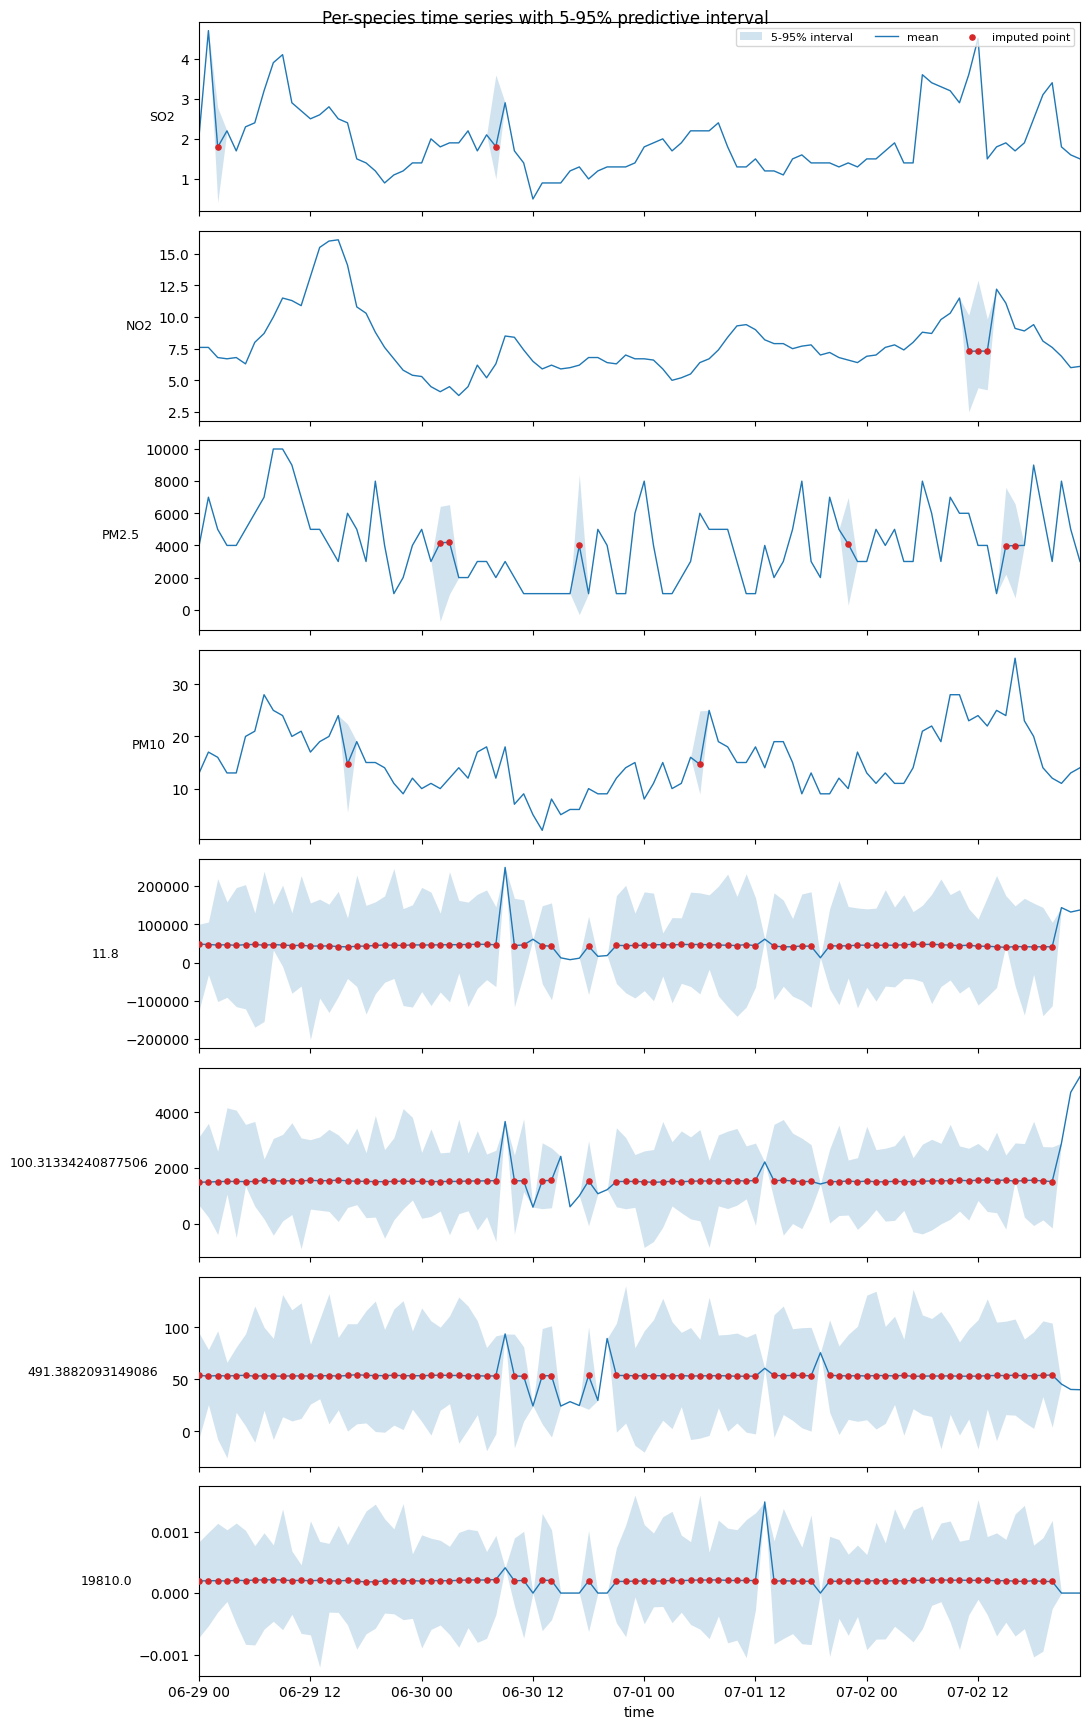

In [8]:
import matplotlib.pyplot as plt

plot_data = result.copy()
plot_data['timestamp'] = pd.to_datetime(plot_data['timestamp'])
features = list(plot_data['feature'].unique())

fig, axes = plt.subplots(len(features), 1, figsize=(11, 2.2 * len(features)), sharex=True)
for ax, feature in zip(axes, features):
    series = plot_data[plot_data['feature'] == feature].sort_values('timestamp')
    ax.fill_between(
        series['timestamp'], series['q05'], series['q95'],
        color='tab:blue', alpha=0.2, linewidth=0, label='5-95% interval',
    )
    ax.plot(series['timestamp'], series['imputed_mean'], color='tab:blue', linewidth=1, label='mean')
    imputed = series[series['is_imputed']]
    ax.scatter(
        imputed['timestamp'], imputed['imputed_mean'],
        color='tab:red', s=14, zorder=3, label='imputed point',
    )
    ax.set_ylabel(feature, rotation=0, ha='right', va='center', fontsize=9)
    ax.margins(x=0)

axes[0].legend(loc='upper right', fontsize=8, ncol=3)
axes[-1].set_xlabel('time')
fig.suptitle('Per-species time series with 5-95% predictive interval')
fig.tight_layout()
plt.show()

## What to do next

For a real dataset, run `validate_multimodal_data` (or `graph-temporal-vae validate-data`) first, choose per-modality transforms/scalers explicitly, train on a sufficiently long period, evaluate on fixed held-out gaps (see `examples/heldout_eval.py`), and inspect performance separately by feature family, gap duration, and context support. Do not treat imputed values as direct measurements.